<a href="https://colab.research.google.com/github/gu5t4d01/IA-para-Ciberseguridad/blob/main/Laboratorio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
column_names = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label"
]
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

data = pd.read_csv(url, names=column_names)

In [6]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,tcp,ftp_data,SF,491,0,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
0,udp,other,SF,146,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
0,tcp,private,S0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
0,tcp,http,SF,232,8153,0,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
0,tcp,http,SF,199,420,0,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
data.shape

(125973, 42)

In [8]:
data["protocol_type"].value_counts()


,count
protocol_type,
http,40338
private,21853
domain_u,9043
smtp,7313
ftp_data,6860
...,...
tftp_u,3
http_8001,2
aol,2


In [9]:
column_names = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

In [10]:
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

data = pd.read_csv(url, names=column_names)

In [11]:
data["protocol_type"].value_counts()

,count
protocol_type,
tcp,102689
udp,14993
icmp,8291


In [12]:
data["service"].value_counts().head(10)


,count
service,
http,40338
private,21853
domain_u,9043
smtp,7313
ftp_data,6860
eco_i,4586
other,4359
ecr_i,3077
telnet,2353


In [13]:
data["label"].value_counts().head(15)

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [14]:
data["tipo_evento"] = data["label"].apply(lambda x: "normal" if x == "normal" else "ataque")

data["tipo_evento"].value_counts()

,count
tipo_evento,
normal,67343
ataque,58630


In [15]:
data["tipo_evento"].value_counts(normalize=True) * 100


,proportion
tipo_evento,
normal,53.458281
ataque,46.541719


In [16]:
data.groupby("tipo_evento")["src_bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_evento,,,,,,,,
ataque,58630.0,82820.141327,8.593025e+06,0.0,0.0,0.0,0.0,1.379964e+09
normal,67343.0,13133.279331,4.181131e+05,0.0,129.0,233.0,324.0,8.958152e+07


In [17]:
data.sort_values("src_bytes", ascending=False)[
    ["protocol_type", "service", "flag", "src_bytes", "dst_bytes", "label", "tipo_evento"]
].head(10)

,protocol_type,service,flag,src_bytes,dst_bytes,label,tipo_evento
125429,tcp,ftp,RSTOS0,1379963888,0,portsweep,ataque
44527,tcp,private,RSTOS0,1167519497,0,portsweep,ataque
60570,tcp,finger,RSTO,693375640,0,portsweep,ataque
43486,tcp,discard,RSTOS0,621568663,0,portsweep,ataque
1038,tcp,telnet,RSTOS0,381709090,0,portsweep,ataque
91546,tcp,smtp,RSTOS0,217277339,0,portsweep,ataque
111229,tcp,X11,SF,89581520,7028652,normal,normal
49323,tcp,X11,SF,24418776,118160,normal,normal
108124,tcp,X11,SF,21945520,98084,normal,normal
45575,tcp,X11,SF,18828976,33116,normal,normal


In [18]:
recon_labels = ["portsweep", "ipsweep", "nmap", "satan"]

data[data["label"].isin(recon_labels)]["label"].value_counts()


,count
label,
satan,3633
ipsweep,3599
portsweep,2931
nmap,1493


In [19]:
recon_total = data[data["label"].isin(recon_labels)].shape[0]

recon_total


11656

In [20]:
(recon_total / len(data)) * 100


9.252776388591206

In [21]:
resumen_recon = data[data["label"].isin(recon_labels)]["label"].value_counts().reset_index()

resumen_recon.columns = ["tipo_ataque", "cantidad"]

resumen_recon["porcentaje_dataset"] = (resumen_recon["cantidad"] / len(data)) * 100

resumen_recon


,tipo_ataque,cantidad,porcentaje_dataset
0,satan,3633,2.883951
1,ipsweep,3599,2.856961
2,portsweep,2931,2.326689
3,nmap,1493,1.185175


<Axes: title={'center': 'Eventos de reconocimiento por tipo de ataque'}, xlabel='tipo_ataque'>

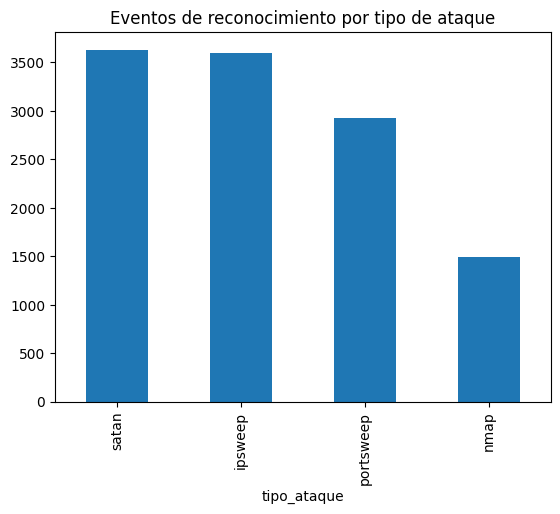

In [22]:
resumen_recon.plot(
    x="tipo_ataque",
    y="cantidad",
    kind="bar",
    legend=False,
    title="Eventos de reconocimiento por tipo de ataque"
)
